In [ ]:
# %% [markdown]
# # 6회차 실습 노트북: 우연성 · 반복 실험 · 분포 · 이상치 · 독립/조건부 사고
#
# ✅ 목표
# - "같은 조건인데 결과가 달라진다"를 직접 체감합니다.
# - 반복 실험을 통해 "분포"가 생기는 과정을 봅니다.
# - boxplot으로 이상치(outlier)를 이해합니다.
# - 독립 vs 조건부(조건을 알면 분포가 달라짐)를 직관적으로 확인합니다.
#
# ⚠️ 오늘은 **공식 암기**가 아니라 **현상 이해**가 목적입니다.
# - 확률을 "예측"이 아니라 "반복 결과의 비율"로 경험합니다.
# - 조건부 확률을 "조건을 알고 나면 판단이 달라진다"로 경험합니다.


In [9]:

# %% 
# ✅ Colab 기본 세팅: 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 재현 가능성을 위해 시드 고정(수업 중에는 바꿔가며 실험해도 좋습니다)
rng = np.random.default_rng(42)

# 출력 옵션(선택)
pd.set_option("display.precision", 4)
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] =False


x1 평균: -0.032932090814718026
x2 평균: 0.10946209602524322
x1 표준편차: 0.8701778230674331
x2 표준편차: 0.7950289467796835


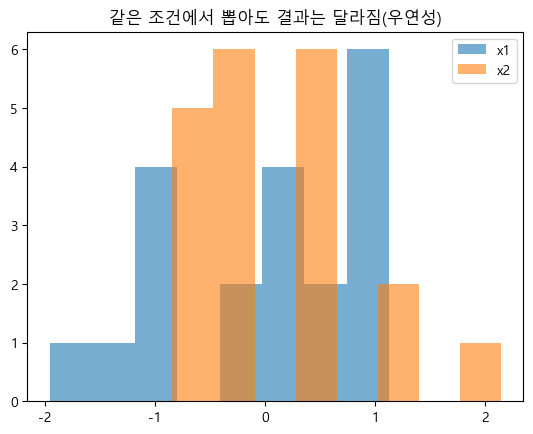

In [10]:

# %% [markdown]
# ## 1) "우연성" 체감: 같은 조건에서도 결과가 다르다
#
# 아래는 완전히 같은 설정으로 난수를 두 번 생성해 비교합니다.
# - 조건: 정규분포(평균 0, 표준편차 1), 표본 크기 20
# - 질문: 평균이 동일할까요? 히스토그램 모양이 같을까요?

# %%
n = 20
x1 = rng.normal(loc=0, scale=1, size=n)
x2 = rng.normal(loc=0, scale=1, size=n)

print("x1 평균:", np.mean(x1))
print("x2 평균:", np.mean(x2))
print("x1 표준편차:", np.std(x1, ddof=1))
print("x2 표준편차:", np.std(x2, ddof=1))

plt.figure()
plt.hist(x1, bins=8, alpha=0.6, label="x1")
plt.hist(x2, bins=8, alpha=0.6, label="x2")
plt.title("같은 조건에서 뽑아도 결과는 달라짐(우연성)")
plt.legend()
plt.show()


n=20 평균들의 표준편차(=평균의 흔들림): 0.2172031391607261
n=200 평균들의 표준편차(=평균의 흔들림): 0.07036409808083437


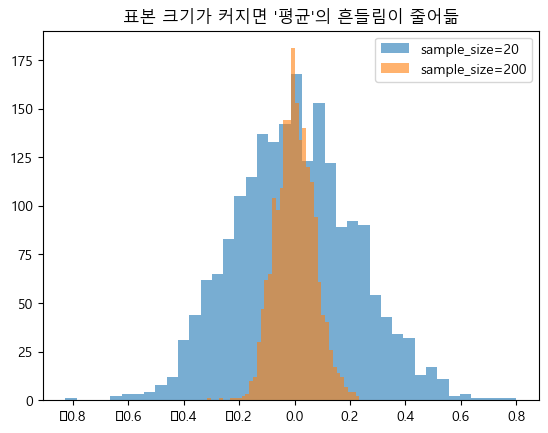

In [8]:

# %% [markdown]
# ✅ 체크 포인트(토론)
# - 평균이 '대표값'이긴 하지만, 표본이 작으면 쉽게 흔들립니다.
# - "한 번 본 데이터"로 단정하기 어렵다는 감각을 얻는 게 목표입니다.

# %% [markdown]
# ## 2) 반복 실험: '한 번'이 아니라 '여러 번' 보면 패턴이 보인다
#
# 같은 실험을 여러 번 반복해서,
# - 각 실험의 평균이 얼마나 흔들리는지(분포)
# - 반복 횟수/표본 크기에 따라 흔들림이 어떻게 바뀌는지
# 를 확인합니다.

# %%
def simulate_means(num_trials: int, sample_size: int, loc=0.0, scale=1.0, rng=None):
    """정규분포에서 sample_size만큼 뽑아 평균을 구하는 실험을 num_trials번 반복."""
    if rng is None:
        rng = np.random.default_rng()
    means = []
    for _ in range(num_trials):
        x = rng.normal(loc=loc, scale=scale, size=sample_size)
        means.append(np.mean(x))
    return np.array(means)

num_trials = 2000

means_n20 = simulate_means(num_trials=num_trials, sample_size=20, rng=rng)
means_n200 = simulate_means(num_trials=num_trials, sample_size=200, rng=rng)

print("n=20 평균들의 표준편차(=평균의 흔들림):", np.std(means_n20, ddof=1))
print("n=200 평균들의 표준편차(=평균의 흔들림):", np.std(means_n200, ddof=1))

plt.figure()
plt.hist(means_n20, bins=40, alpha=0.6, label="sample_size=20")
plt.hist(means_n200, bins=40, alpha=0.6, label="sample_size=200")
plt.title("표본 크기가 커지면 '평균'의 흔들림이 줄어듦")
plt.legend()
plt.show()


A 평균/표준편차: 49.81641793797408 5.028421820728067
B 평균/표준편차: 49.82161541516387 14.935055104728688


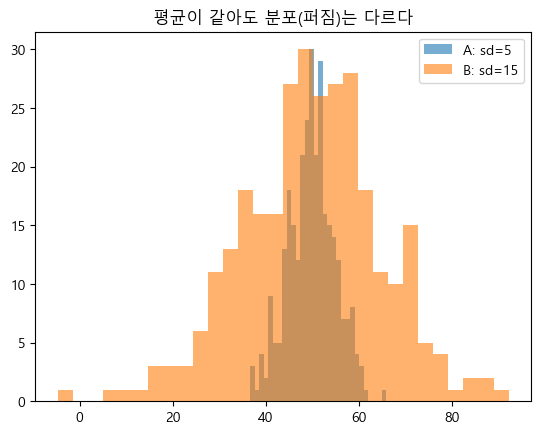

In [12]:

# %% [markdown]
# ✅ 질문(핵심)
# - 왜 표본 크기 200일 때 평균 분포가 더 "좁아"졌을까요?
# - 이 '좁아짐'은 다음 회차에서 **표준오차**, **신뢰구간**으로 이어집니다.
#
# (실습 팁) sample_size를 5, 10, 50, 1000으로 바꿔보세요.

# %% [markdown]
# ## 3) 분포 감각: 평균이 같아도 분포는 다를 수 있다
#
# 평균이 같은 두 그룹을 만들되,
# - A: 변동이 작은 그룹
# - B: 변동이 큰 그룹
# 으로 구성해 "평균만 보고 판단하면 위험"함을 봅니다.

# %%
n = 300
A = rng.normal(loc=50, scale=5, size=n)   # 변동 작음
B = rng.normal(loc=50, scale=15, size=n)  # 변동 큼

print("A 평균/표준편차:", np.mean(A), np.std(A, ddof=1))
print("B 평균/표준편차:", np.mean(B), np.std(B, ddof=1))

plt.figure()
plt.hist(A, bins=30, alpha=0.6, label="A: sd=5")
plt.hist(B, bins=30, alpha=0.6, label="B: sd=15")
plt.title("평균이 같아도 분포(퍼짐)는 다르다")
plt.legend()
plt.show()


In [ ]:

# %% [markdown]
# ✅ 토론 포인트
# - "둘 다 평균 50이니 비슷하다"는 말은 얼마나 위험할까요?
# - 분산/표준편차는 '데이터가 얼마나 흔들리는지'를 숫자로 말해줍니다.


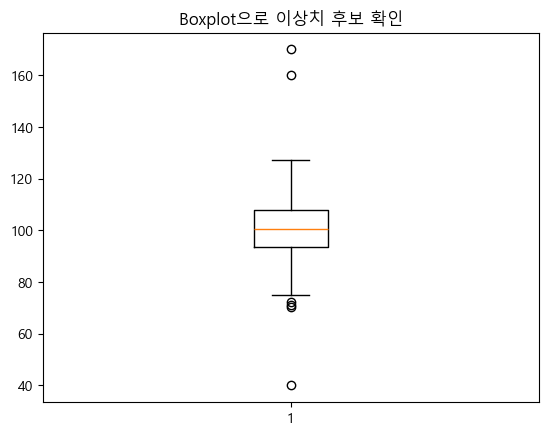

Q1, Q3, IQR: 93.73957290302499 107.85136356804803 14.111790665023037
이상치 후보 구간: 72.57188690549043 ~ 129.01904956558258
이상치 후보 값들: [ 40.          70.44381176  71.32945046  72.22005719 160.
 170.        ]


In [13]:

# %% [markdown]
# ## 4) 박스플롯과 이상치: 평균이 못 보는 정보
#
# boxplot은
# - 중앙값, 사분위수(IQR), 이상치 후보
# 를 한 번에 보여줍니다.
#
# 이번 파트는 "이상치 = 무조건 제거"가 아니라,
# **이상치 = 질문을 던지는 값**이라는 관점을 연습합니다.

# %%
# 기본 데이터 + 일부러 이상치 섞기
base = rng.normal(loc=100, scale=10, size=200)
outliers = np.array([160, 170, 40])  # 의도적 이상치
X = np.concatenate([base, outliers])

plt.figure()
plt.boxplot(X, vert=True)
plt.title("Boxplot으로 이상치 후보 확인")
plt.show()

# 이상치 판별(교육용): IQR 규칙
q1 = np.percentile(X, 25)
q3 = np.percentile(X, 75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

candidates = X[(X < lower) | (X > upper)]

print("Q1, Q3, IQR:", q1, q3, iqr)
print("이상치 후보 구간:", lower, "~", upper)
print("이상치 후보 값들:", np.sort(candidates))


In [14]:

# %% [markdown]
# ✅ 질문(이상치 토론)
# - 이 이상치 후보는 "측정 오류"일까요, "진짜 특이 사례"일까요?
# - 만약 이것이 특정 조건(예: 주말, 이벤트, 특정 고객군)에서만 발생한다면?
#   → 다음 파트의 "조건"과 연결됩니다.

# %% [markdown]
# ## 5) "사건"과 "확률": 반복 결과의 비율로 이해하기
#
# 확률을 수식보다 먼저 이렇게 정의해봅니다:
# - 같은 실험을 여러 번 반복했을 때,
# - 어떤 결과(=사건)가 차지하는 비율
#
# 예: "값이 0보다 크다" 라는 사건을 만들고
# 반복 실험에서 비율을 계산해 봅니다.

# %%
def event_rate(num_trials: int, sample_size: int, threshold: float = 0.0, rng=None):
    """
    사건: '표본 평균이 threshold보다 크다'
    - 같은 실험을 num_trials번 반복하고
    - 그 중 사건이 일어난 비율을 반환
    """
    if rng is None:
        rng = np.random.default_rng()
    means = simulate_means(num_trials, sample_size, loc=0.0, scale=1.0, rng=rng)
    return np.mean(means > threshold)  # True의 평균은 비율(확률의 경험적 추정)

for ss in [5, 20, 100]:
    rate = event_rate(num_trials=5000, sample_size=ss, threshold=0.0, rng=rng)
    print(f"sample_size={ss} 일 때 P(표본평균 > 0) 추정값:", rate)

# %% [markdown]
# ✅ 여기서 포인트
# - 우리는 "정답 확률"을 외우는 게 아니라,
#   **반복 결과의 비율**로 확률을 경험했습니다.
# - 표본 크기가 바뀌면 사건의 비율(추정값)도 변할 수 있습니다.
#   → 이런 흔들림을 다음 회차에서 신뢰구간으로 다룹니다.

# %% [markdown]
# ## 6) 독립 vs 조건부 사고: 조건을 알면 분포가 달라진다
#
# 핵심 문장:
# - 독립: A를 알아도 B가 달라지지 않는다
# - 조건부: 조건을 알면 B의 분포가 달라진다
#
# 실습 전략:
# 1) 독립인 데이터 생성: X와 Y를 따로 생성
# 2) 조건부 관계 데이터 생성: 조건에 따라 Y의 평균이 달라지게 생성
# 3) 그룹별 분포(박스플롯)로 "조건을 알면 판단이 달라짐"을 확인


sample_size=5 일 때 P(표본평균 > 0) 추정값: 0.5074
sample_size=20 일 때 P(표본평균 > 0) 추정값: 0.4868
sample_size=100 일 때 P(표본평균 > 0) 추정값: 0.4954


독립 사례 corr(X, Y): -0.03353537198485386
조건부 사례 corr(X, Y): 0.5521367854276852


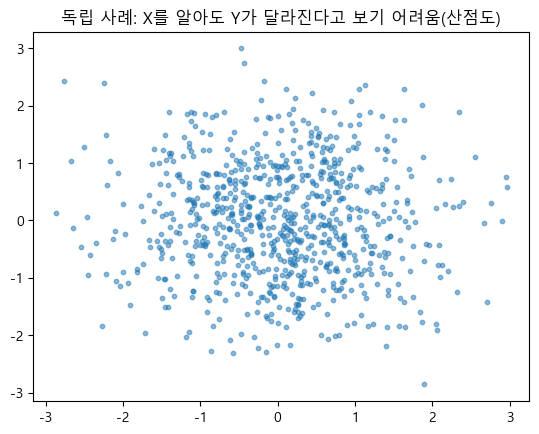

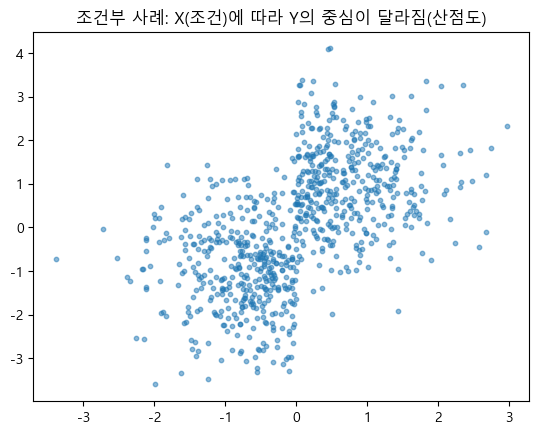

C:\Users\giveroot\AppData\Local\Temp\ipykernel_604372\63857170.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([group0, group1], labels=["C=0 (X<0)", "C=1 (X>=0)"])


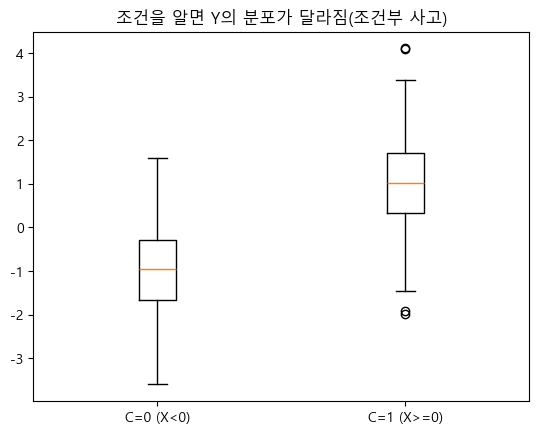

In [15]:

# %%
N = 800

# (1) 독립 사례: X, Y가 서로 영향 없도록 각각 생성
X_ind = rng.normal(0, 1, size=N)
Y_ind = rng.normal(0, 1, size=N)

# (2) 조건부 사례:
# 조건 C는 X의 부호로 정의(간단한 조건)
# - X>=0인 그룹에서는 Y의 평균을 +1
# - X<0인 그룹에서는 Y의 평균을 -1
X_cond = rng.normal(0, 1, size=N)
C = (X_cond >= 0).astype(int)  # 조건(0/1)
Y_cond = rng.normal(loc=np.where(C == 1, 1.0, -1.0), scale=1.0, size=N)

# 상관계수로 참고(수업에서는 "정답"이 아니라 "힌트" 정도로)
corr_ind = np.corrcoef(X_ind, Y_ind)[0, 1]
corr_cond = np.corrcoef(X_cond, Y_cond)[0, 1]
print("독립 사례 corr(X, Y):", corr_ind)
print("조건부 사례 corr(X, Y):", corr_cond)

# 시각화 1: 산점도 비교
plt.figure()
plt.scatter(X_ind, Y_ind, s=10, alpha=0.5)
plt.title("독립 사례: X를 알아도 Y가 달라진다고 보기 어려움(산점도)")
plt.show()

plt.figure()
plt.scatter(X_cond, Y_cond, s=10, alpha=0.5)
plt.title("조건부 사례: X(조건)에 따라 Y의 중심이 달라짐(산점도)")
plt.show()

# 시각화 2: 조건별(그룹별) Y 분포 비교(박스플롯)
df = pd.DataFrame({"C": C, "Y": Y_cond})
group0 = df.loc[df["C"] == 0, "Y"]
group1 = df.loc[df["C"] == 1, "Y"]

plt.figure()
plt.boxplot([group0, group1], labels=["C=0 (X<0)", "C=1 (X>=0)"])
plt.title("조건을 알면 Y의 분포가 달라짐(조건부 사고)")
plt.show()


In [16]:

# %% [markdown]
# ✅ 토론(핵심)
# - 전체 Y를 한 덩어리로 보면 평균이 0 근처일 수도 있습니다.
# - 하지만 조건 C를 알고 나면,
#   - C=0일 때 평균은 -1 근처
#   - C=1일 때 평균은 +1 근처
#   로 '판단'이 달라집니다.
#
# 이것이 조건부 확률의 본질(공식 없이):
# **조건을 알면 분포가 달라진다 → 결론이 달라진다**
#
# 이 감각이 회귀분석(9회차)의 출발점입니다:
# "다른 조건을 통제했을 때의 관계"를 수식으로 표현하는 것.

# %% [markdown]
# ## 7) (미니 과제) 오늘의 핵심을 말로 설명하기
#
# 아래 질문에 대해, 코드 결과(그래프)를 근거로 한 문장씩 써보세요.
#
# 1) 같은 조건인데 평균이 달라질 수 있는 이유는?
# 2) 표본 크기가 커질수록 평균의 분포가 왜 좁아지는가?
# 3) 이상치를 보면 어떤 '질문'을 던져야 하는가?
# 4) 조건을 알면 판단이 달라진다는 것을 오늘 실습에서 어떻게 확인했는가?
#
# (선택) 여러분이 관심 있는 "조건"을 하나 더 만들어서,
# 그룹별 박스플롯을 그려보고 설명해 보세요.


---
---
---


In [18]:
# %% [markdown]
# # 6회차 리디자인 실습: "값"이 아니라 "결론(판단)"이 흔들리는 구조 체험
#
# ✅ 이번 노트북의 핵심(이전 2~5회차와의 차별점)
# - (이전) 평균/표준편차/분포를 "설명"하는 데 초점
# - (이번) **같은 기준으로 판단했는데도 결론이 바뀌는 이유**를 체험
#
# ✅ 오늘의 3가지 경험(6회차 전용)
# 1) 사건(Event)을 먼저 정의한다: 예) "평균이 50보다 크다"
# 2) 반복 실험을 통해, 그 사건이 일어나는 비율이 흔들린다는 걸 본다
# 3) 조건을 알기 전/후에 결론 문장이 완전히 달라질 수 있음을 본다
#
# ⚠️ 약속
# - 공식(조건부확률 공식, 표준오차 공식 등)로 밀지 않습니다.
# - 대신 "왜 그렇게 말할 수밖에 없는가"를 실험으로 납득합니다.
#
# (Colab 사용 가정) 실행 순서: 위에서 아래로 셀을 차례대로 실행하세요.

# %% 
# ✅ 기본 세팅
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
pd.set_option("display.precision", 4)

# %% [markdown]
# ---
# ## 0) 오늘의 큰 질문(수업 시작에 던질 질문)
# 
# > "같은 기준으로 판단했는데, 왜 결론이 바뀌지?"
#
# 오늘은 아래처럼 "판단 기준"을 먼저 정해놓고 실험합니다.
#
# - 사건(Event) 1: "표본 평균이 50보다 크다"
# - 사건(Event) 2: "두 집단 평균이 다르다(한 집단이 더 크다)"
#
# 그리고 반복 실험을 통해 묻습니다.
# - 이 판단은 얼마나 자주 뒤집히는가?
# - 어떤 조건(표본 크기/변동성/조건 정보)에 따라 달라지는가?

# %% [markdown]
# ---
# ## 1) 사건(Event)부터 시작하기: "평균 > 50"이라는 판단은 얼마나 자주 뒤집히나?
#
# ### 왜 이게 6회차다운가?
# - 우리는 "평균이 얼마"를 설명하려는 게 아닙니다.
# - **"평균이 50보다 크다"라는 결론(판단)이 얼마나 자주 바뀌는지**를 봅니다.
#
# ### 실험 설계
# - 진짜(모집단) 평균이 50인 세계를 가정
# - 그 세계에서 표본을 뽑아 평균을 계산
# - 사건: (표본평균 > 50) 이 True/False가 되는지 기록
# - 이 과정을 수천 번 반복해서 "True 비율"을 확인

# %%
def trial_event_mean_gt_threshold(sample_size: int, mu: float, sigma: float, threshold: float, rng):
    """
    한 번의 실험(trial):
    - N(mu, sigma^2)에서 sample_size개 샘플 생성
    - 표본 평균이 threshold를 넘으면 True(사건 발생), 아니면 False
    """
    x = rng.normal(loc=mu, scale=sigma, size=sample_size)
    return np.mean(x) > threshold

def simulate_event_rate(num_trials: int, sample_size: int, mu: float, sigma: float, threshold: float, rng):
    """사건 발생 비율(=반복 결과의 비율)을 계산"""
    results = [trial_event_mean_gt_threshold(sample_size, mu, sigma, threshold, rng) for _ in range(num_trials)]
    return np.mean(results), np.array(results, dtype=int)

# 실험 파라미터
num_trials = 5000
mu = 50.0
sigma = 10.0
threshold = 50.0  # "평균이 50보다 큰가?"라는 판단 기준

for n in [5, 20, 100]:
    rate, _ = simulate_event_rate(num_trials, n, mu, sigma, threshold, rng)
    print(f"표본크기 n={n} 일 때, 사건(표본평균 > 50) 발생 비율:", rate)


표본크기 n=5 일 때, 사건(표본평균 > 50) 발생 비율: 0.5064
표본크기 n=20 일 때, 사건(표본평균 > 50) 발생 비율: 0.4876
표본크기 n=100 일 때, 사건(표본평균 > 50) 발생 비율: 0.5034


n=20, 200번 실험 중 True(1) 비율: 0.525


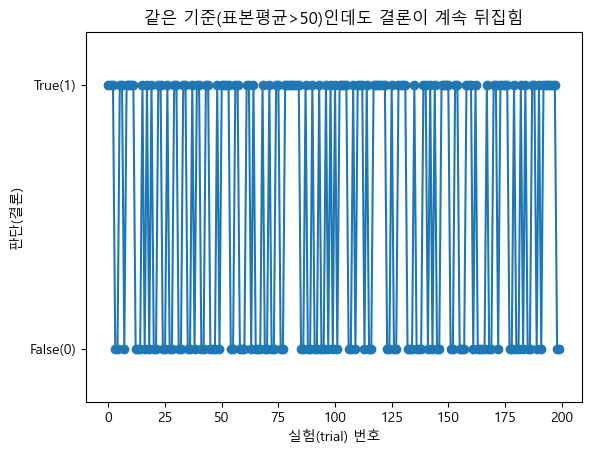

In [ ]:

# %% [markdown]
# ✅ 토론(핵심)
# - "진짜 평균(mu)은 50"으로 고정했는데,
#   표본으로 판단한 결과(표본평균 > 50)는 항상 0%도 아니고 100%도 아닙니다.
# - 즉, **표본으로 하는 판단은 본질적으로 흔들립니다.**
#
# 다음 질문:
# > "그 흔들림이 줄어드는 조건은 무엇일까?"
# 바로 표본 크기입니다. (7회차의 문을 엽니다)-

# %% [markdown]
# ---
# ## 2) '결론'의 흔들림을 눈으로 보기: 여러 번 반복한 판단 결과(0/1) 시각화
#
# 여기서 그래프는 "분포 설명"이 목적이 아닙니다.
# **결론이 0/1로 계속 뒤집히는 모습을 보여주는 장치**입니다.

# %%
n = 20
rate, decisions = simulate_event_rate(num_trials=200, sample_size=n, mu=mu, sigma=sigma, threshold=threshold, rng=rng)

print("n=20, 200번 실험 중 True(1) 비율:", rate)

plt.figure()
plt.plot(decisions, marker="o", linestyle="-")
plt.ylim(-0.2, 1.2)
plt.yticks([0, 1], ["False(0)", "True(1)"])
plt.title("같은 기준(표본평균>50)인데도 결론이 계속 뒤집힘")
plt.xlabel("실험(trial) 번호")
plt.ylabel("판단(결론)")
plt.show()

# %% [markdown]
# ✅ 질문
# - 이 그래프를 보고 "단정"할 수 있을까요?
# - 단정 대신, 우리는 어떤 말투로 말해야 할까요?
#   예: "대체로", "대부분", "확률적으로", "그럴 가능성이"
#
# -> 이 말투가 바로 확률적 사고의 핵심입니다.


In [20]:

# %% [markdown]
# ---
# ## 3) 같은 평균, 다른 변동성: 변동성(sigma)이 커지면 결론은 더 흔들릴까?
#
# 2~5회차에서는 표준편차를 "설명"하는 데 집중했을 수 있습니다.
# 6회차에서는 **표준편차가 커질수록 '판단이 더 불안정해진다'**를 체험합니다.

# %%
sigmas = [5, 10, 20]
n = 20

rows = []
for s in sigmas:
    rate, _ = simulate_event_rate(num_trials=5000, sample_size=n, mu=mu, sigma=s, threshold=threshold, rng=rng)
    rows.append({"sample_size": n, "sigma": s, "event_rate(P(mean>50))": rate})

pd.DataFrame(rows)


,sample_size,sigma,event_rate(P(mean>50))
0,20,5,0.4996
1,20,10,0.5036
2,20,20,0.5002


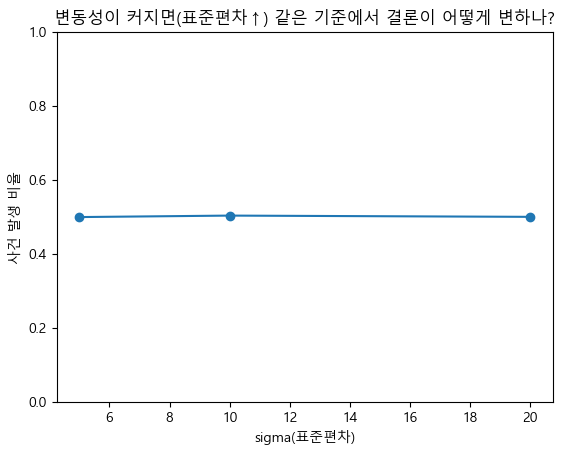

In [21]:

# %%
# 시각화: sigma에 따른 사건 비율 비교
df_sigma = pd.DataFrame(rows)

plt.figure()
plt.plot(df_sigma["sigma"], df_sigma["event_rate(P(mean>50))"], marker="o")
plt.title("변동성이 커지면(표준편차↑) 같은 기준에서 결론이 어떻게 변하나?")
plt.xlabel("sigma(표준편차)")
plt.ylabel("사건 발생 비율")
plt.ylim(0, 1)
plt.show()

# %% [markdown]
# ✅ 토론(핵심)
# - 변동성이 커지면, 표본 평균이 threshold(50)를 넘는지 여부가 더 들쑥날쑥해질 수 있습니다.
# - 즉, 변동성은 "수치 설명"이 아니라 **판단 안정성**과 직결됩니다.


In [22]:

# %% [markdown]
# ---
# ## 4) (중요) 조건을 알기 전/후: 결론 문장이 바뀌는 경험
#
# 이번 파트는 "조건부 확률"을 **공식 없이** 체감하는 핵심 실습입니다.
#
# ### 시나리오(수업용 이야기)
# - 어떤 정책/처치/교육의 효과를 보려 한다.
# - 전체로 보면 효과가 없어 보이는데,
# - 조건(집단 특성)을 나누면 효과가 보인다(또는 반대).
#
# 이 구조는 회귀분석의 출발점과 닿아 있습니다:
# - "다른 조건을 통제하면 관계가 달라질 수 있다"

# %%
# 조건(C): 0 또는 1 (두 집단)
N = 2000
C = rng.integers(0, 2, size=N)  # 0/1 두 그룹

# 처치(T): 0 또는 1
T = rng.integers(0, 2, size=N)

# 결과(Y)를 생성하는 규칙(설계):
# - 전체로 보면 T의 효과가 약하거나 없어 보이도록 만들되
# - 조건 C에 따라 baseline이 다르고, T의 효과도 다르게 만들어
#   "조건을 알고 보면 결론이 달라지는" 상황을 만든다.
#
# 예시 규칙:
# - C=0 그룹: baseline 낮음, T의 효과는 +3
# - C=1 그룹: baseline 높음, T의 효과는 +0 (효과 없음)
# 또한 C=1 그룹에 T=1이 더 많이 배정되게 만들어(관찰데이터 느낌),
# 전체 평균 비교가 헷갈리도록 한다(조건의 중요성 강조용).

# (관찰데이터 느낌을 위해) T를 C에 의존시키기: C=1이면 T=1일 확률을 높임
prob_T1 = np.where(C == 1, 0.75, 0.25)
T = (rng.random(N) < prob_T1).astype(int)

# 결과 생성
noise = rng.normal(0, 5, size=N)
baseline = np.where(C == 1, 60, 40)
effect_T = np.where(C == 0, 3, 0)  # C=0에서만 효과
Y = baseline + effect_T * T + noise

df = pd.DataFrame({"C": C, "T": T, "Y": Y})

df.head()


,C,T,Y
0,1,1,52.1359
1,1,1,53.4506
2,0,0,38.5216
3,0,0,38.0089
4,1,1,56.0339


조건 무시(전체) 평균:
T=0 평균: 45.075907189884916
T=1 평균: 55.885733353461504
차이(T=1 - T=0): 10.809826163576588


C:\Users\giveroot\AppData\Local\Temp\ipykernel_604372\4090038202.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df.loc[df["T"] == 0, "Y"], df.loc[df["T"] == 1, "Y"]], labels=["T=0", "T=1"])


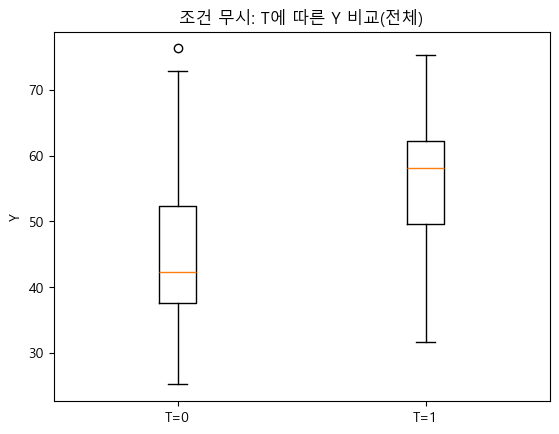

In [23]:

# %% [markdown]
# ### 4-1) 조건을 무시한 결론: "T=1이 더 크다/작다"?
# 먼저 조건 C를 무시하고, 단순 비교(전체 평균)만 해봅니다.
# 이 단계가 바로 "조건 없이 판단"입니다.

# %%
mean_T0 = df.loc[df["T"] == 0, "Y"].mean()
mean_T1 = df.loc[df["T"] == 1, "Y"].mean()
diff_all = mean_T1 - mean_T0

print("조건 무시(전체) 평균:")
print("T=0 평균:", mean_T0)
print("T=1 평균:", mean_T1)
print("차이(T=1 - T=0):", diff_all)

plt.figure()
plt.boxplot([df.loc[df["T"] == 0, "Y"], df.loc[df["T"] == 1, "Y"]], labels=["T=0", "T=1"])
plt.title("조건 무시: T에 따른 Y 비교(전체)")
plt.ylabel("Y")
plt.show()

# %% [markdown]
# ✅ 여기서 학생에게 던질 질문(중요)
# - "그럼 결론은 T가 효과가 있다/없다/나쁘다 중 무엇일까요?"
# - 하지만 아직은 성급합니다. 우리는 조건(C)을 무시했습니다.


C:\Users\giveroot\AppData\Local\Temp\ipykernel_604372\1789365787.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(group_data, labels=labels)


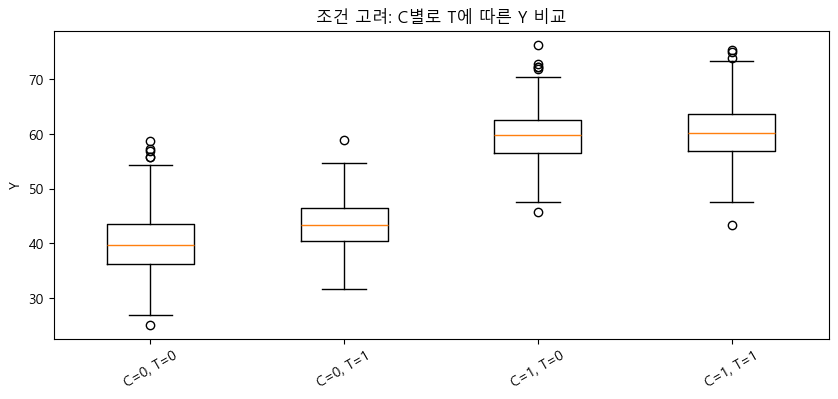

In [24]:

# %% [markdown]
# ### 4-2) 조건을 고려한 결론: C별로 나눠서 다시 비교
# 이제 조건 C를 알고 나서(=정보가 추가된 상태)
# 같은 비교를 다시 합니다.
#
# 이것이 조건부 사고의 핵심:
# - "조건을 알면 판단이 달라질 수 있다"

# %%
summary = []
for c in [0, 1]:
    sub = df[df["C"] == c]
    m0 = sub.loc[sub["T"] == 0, "Y"].mean()
    m1 = sub.loc[sub["T"] == 1, "Y"].mean()
    summary.append({"C": c, "mean_T0": m0, "mean_T1": m1, "diff(T1-T0)": m1 - m0})

pd.DataFrame(summary)

# %%
# 시각화: C별로 boxplot
group_data = []
labels = []
for c in [0, 1]:
    group_data.append(df[(df["C"] == c) & (df["T"] == 0)]["Y"])
    labels.append(f"C={c}, T=0")
    group_data.append(df[(df["C"] == c) & (df["T"] == 1)]["Y"])
    labels.append(f"C={c}, T=1")

plt.figure(figsize=(10, 4))
plt.boxplot(group_data, labels=labels)
plt.title("조건 고려: C별로 T에 따른 Y 비교")
plt.ylabel("Y")
plt.xticks(rotation=30)
plt.show()


In [25]:

# %% [markdown]
# ✅ 토론(핵심 결론 만들기)
# - 조건 무시(전체) 결론: diff = 위에서 계산한 값
# - 조건 고려(C별) 결론: C=0에서는 T 효과가 보이고, C=1에서는 거의 안 보일 수 있음
#
# 이때 학생이 반드시 말해야 하는 문장:
# > "조건을 무시하면 결론이 달라질 수 있다."
#
# 여기서 확률/조건부 확률의 공식이 아니라,
# **판단의 기준이 바뀌는 경험**을 남기는 게 목표입니다.

# %% [markdown]
# ---
# ## 5) (미니) 독립 감각: 조건이 진짜로 의미가 있으려면?
#
# 방금은 C가 사실상 중요한 조건이었습니다.
# 그렇다면 "독립"은 어떤 상황일까요?
#
# 독립의 직관(오늘 수준):
# - 조건을 알고 나서도 결론이 달라지지 않는다면,
#   그 조건은 적어도 지금 맥락에서는 영향이 약하다고 볼 수 있습니다.
#
# 아래는 "의미 없는 조건"을 하나 만들어서
# 조건 전/후 결론이 거의 안 바뀌는 사례를 비교합니다.


In [ ]:

# %%
# 의미 없는 조건 D (Y 생성에 영향이 없도록 그냥 랜덤)
D = rng.integers(0, 2, size=N)
df2 = df.copy()
df2["D"] = D

# 조건 D를 무시한 비교
m0 = df2.loc[df2["T"] == 0, "Y"].mean()
m1 = df2.loc[df2["T"] == 1, "Y"].mean()
print("D 무시(전체) diff:", m1 - m0)

# 조건 D를 고려한 비교
summary_D = []
for d in [0, 1]:
    sub = df2[df2["D"] == d]
    m0d = sub.loc[sub["T"] == 0, "Y"].mean()
    m1d = sub.loc[sub["T"] == 1, "Y"].mean()
    summary_D.append({"D": d, "diff(T1-T0)": m1d - m0d})

pd.DataFrame(summary_D)

# %% [markdown]
# ✅ 토론
# - D는 Y에 영향을 주도록 만들지 않았습니다.
# - 그래서 D를 알고 나서 결론이 크게 바뀌지 않는다면,
#   "이 조건은 (적어도 지금 데이터 생성 구조에서는) 중요하지 않다"는 감각을 얻습니다.
#
# ⚠️ 중요한 주의
# - 현실에서는 "중요하지 않아 보이는 조건"도, 다른 맥락에서는 중요해질 수 있습니다.
# - 그래서 통계/회귀에서 '조건 선택'이 중요합니다(9회차의 연결 포인트).

# %% [markdown]
# ---
# ## 6) 오늘의 정리(학생이 말로 해야 하는 것)
#
# 아래 문장을 학생이 직접 완성해 보게 하세요.
#
# 1) 같은 기준으로 판단했는데 결론이 바뀌는 이유는 ________ 때문이다.
# 2) 표본 크기가 커지면 결론이 덜 흔들리는 이유는 ________ 때문이다. (힌트: 평균의 안정성)
# 3) 조건을 알기 전/후 결론이 달라질 수 있다는 것은 ________ 사고의 핵심이다.
# 4) 회귀분석은 결국 "__________을(를) 통제했을 때의 관계"를 말하려는 도구다.
#
# (선택 과제)
# - threshold(50)를 52 또는 48로 바꾸면 사건 발생 비율이 어떻게 변하는지 실험해 보세요.
# - sigma를 30으로 키우면 결론 흔들림이 어떻게 변하는지 확인해 보세요.
# - C=0에서의 효과를 +6으로 바꾸면 조건 고려 결론이 어떻게 변하는지 확인해 보세요.
